<a href="https://colab.research.google.com/github/MK1250/AI_Mascot_Credit-Card-Default_Prediction/blob/main/Week4_Starter_Notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Week 4 Assignment Starter Notebook
**Battle of the Neural Network Mascots – Credit Default Edition**

📌 **Instructions:**
- Complete your model in accordance with your assigned personality rules.
- Do NOT modify the dataset preparation block.
- Train and validate your model, then report test accuracy.
- Include training vs validation plots and a short reflection.
- Log your AI interactions if you use Deep Learning Buddy.


#  **Description:**
  *Project by: Maria Contreras*

  Chosen Personality: Activation Artist - *Express Yourself*
  
  Activations: tanh; ReLU; Softmax

  Layer Sizes:23 tanh then 8 relu, then 2 softmax

  Optimizers: batch size 1000; epochs 60

In [72]:
# 🚫 DO NOT MODIFY THIS BLOCK
# Starter Code for Week 4 - Dataset Preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Drop ID column
df = df.drop(columns=["ID"])

# Split features and labels
X = df.drop(columns=["default"]).values
y = df["default"].values

# Split into train (60%), temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
# Split temp into validation (20%) and test (20%)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print("Data split complete.")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_valid.shape}")
print(f"Test set: {X_test.shape}")

Data split complete.
Training set: (18000, 23)
Validation set: (6000, 23)
Test set: (6000, 23)


## *Step 1: Define the Keras Model*

In [73]:
# Keras Import
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# keeping weigths the same:
tf.keras.utils.set_random_seed(42)

# define the sequential model
model = Sequential([
    Dense(23, activation = 'tanh', input_shape = (X_train.shape[1],)),
    Dense(8, activation = 'relu'),
    Dense(2, activation = 'softmax')
])

# Compile the model
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## *Step 2: Train the Model*

In [71]:
history = model.fit(X_train, y_train, epochs = 60, validation_data = (X_valid, y_valid), batch_size =1000)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4798 - loss: 0.7445 - val_accuracy: 0.5485 - val_loss: 0.6785
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6156 - loss: 0.6323 - val_accuracy: 0.6803 - val_loss: 0.6101
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7415 - loss: 0.5775 - val_accuracy: 0.7592 - val_loss: 0.5726
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7857 - loss: 0.5450 - val_accuracy: 0.7810 - val_loss: 0.5451
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7984 - loss: 0.5189 - val_accuracy: 0.7915 - val_loss: 0.5209
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8032 - loss: 0.4979 - val_accuracy: 0.7967 - val_loss: 0.5030
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8065 - loss: 0.4834 - val_accuracy: 0.7997 - val_loss: 0.4908
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8074 - loss: 0.4736 - val_accuracy: 0.8007 - v

## *Step 6: Evaluate the Model*

In [74]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Testing Accuracy: {accuracy: .2f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3898 - loss: 0.8283
Testing Accuracy:  0.39


In [75]:
# How many 0 vs 1
preds = model.predict(X_valid).argmax(axis=1)
print(np.bincount(preds))

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1581 4419]


## *Step 7: Visualization of Testing and Valiadation Accuracy*

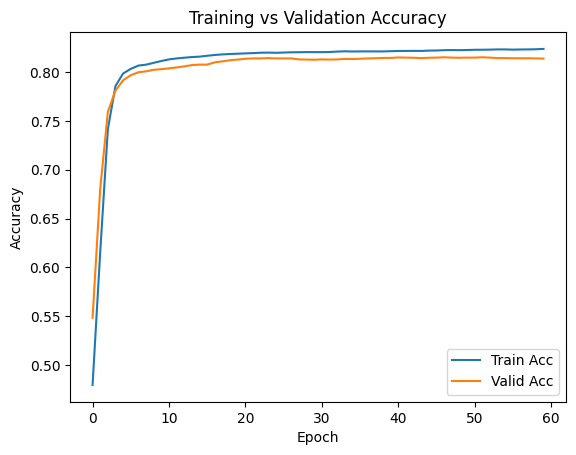

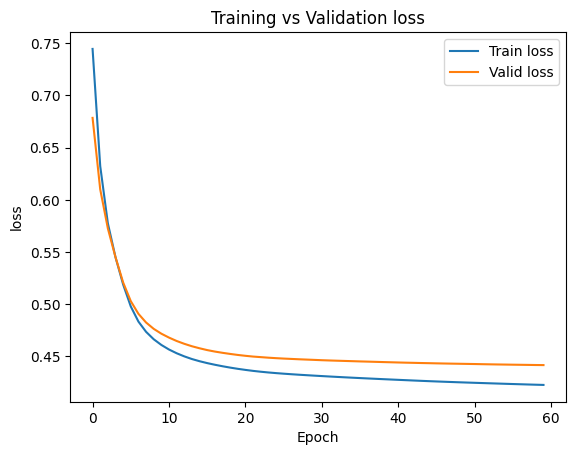

In [76]:
# Visualization taken from Keras_Titanic_Binary_Classification_Demo.ipynb

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label = 'Train Acc')
plt.plot(history.history['val_accuracy'], label = 'Valid Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Valid loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('Training vs Validation loss')
plt.legend()
plt.show()



### Explain trining vs validation curves:


*   At what epoch (approximately) do your training and validation curves start to diverge, if they do?

    * *My trining and validation curves start to diverge aproximately at epoch 8*
*   Is there any evidence of overfitting, underfitting, or neither? What in your curve specifically tells you that?

    * *There is evidence of neither overfiting or underfitting*
        * *Evidence of overfitting would mean that the validation curve would diverge dramatically from the training curve. Infact I go into more detail later but it was surprisingly hard to overfit this particular model even after 600, 1000 and 1800 epochs.*
        * *Evidence of underfiting would mean the validation curves and training courves would show as a complete separation between the validation and training accuracy/loss. not shown here*
        * *I know my curve is neither because they do not converge early, their fairly close but not almost overlaping or completely segregated.*
*   How does this relate to your assigned personality's constraint — did the constraint make one of these more or less likely?
    * *The constraint made overfiting way less likely. I know I am repeting this a lot but I passed almost 1000 epochs, it took 10 minutes and still, no overfitting.*
    * *Underfiting on the other hand was the one which gave me the most problems, it took me a few tries in which the model would stay at 78% accuracy, according to claude that is a common trait on this dataset. Adding 23 neurons for tanh was what fixed that.*



### *Notes*

Fixed a missing comma in the model definition


Fixed a typo in the matplotlib import

Changed the first layer from 2 to 23 tanh neurons, then back to 2, then to 23 again; stayed on 23 tanh neurons since those got rid of model choosing the majority 78% ok plateau.

Changed the output layer from 1 sigmoid to 2 softmax neurons

Changed the loss from binary_crossentropy to sparse_categorical_crossentropy to
match the softmax output

Tried batch sizes of 32 (default), 40, 50, and 1000

Tried 20, 30, 60, 100, 600, 1000 and up to 18000 epochs

Switched validation from validation_split=0.2 to the provided X_valid and
y_valid

Fixed the loss plot's title and axis labels

Decided not to add a fourth activation layer

 *ps. this list is an aproximation, it's mustly the debugs I asked claude to help me with cause I forgot to keep track of everything I did, But i did take a few pictures:*



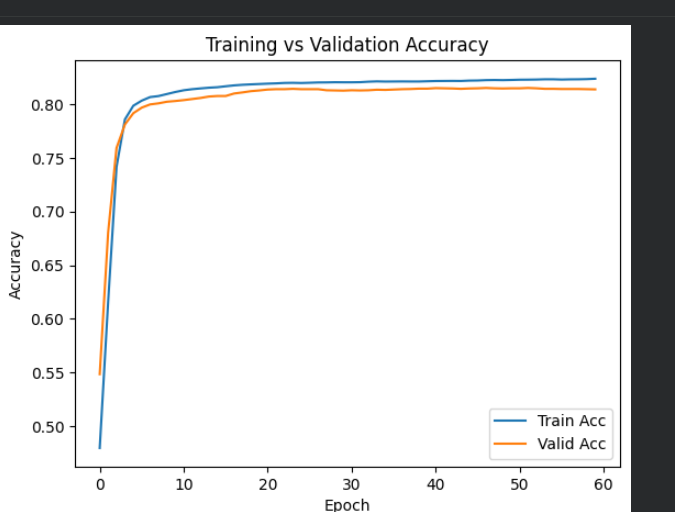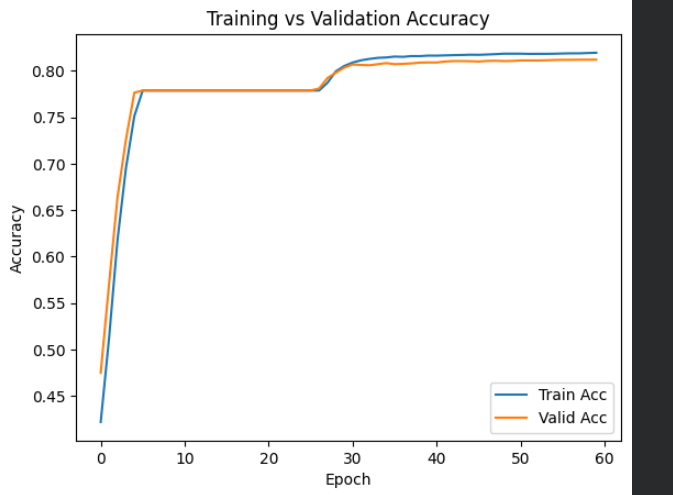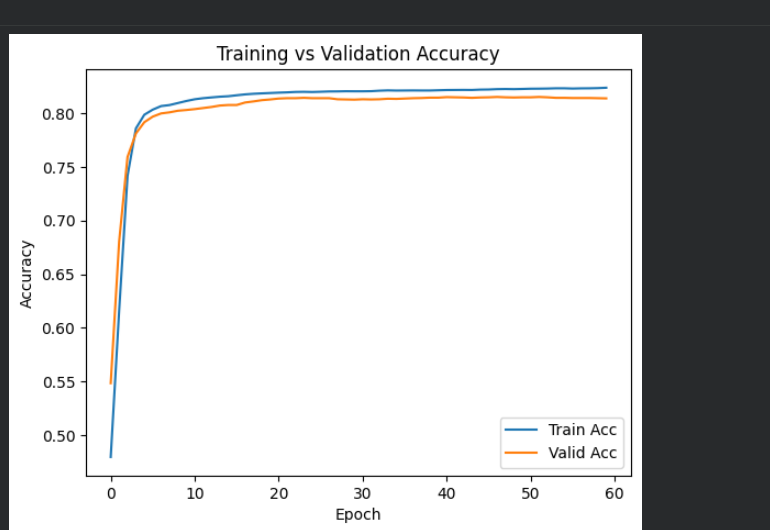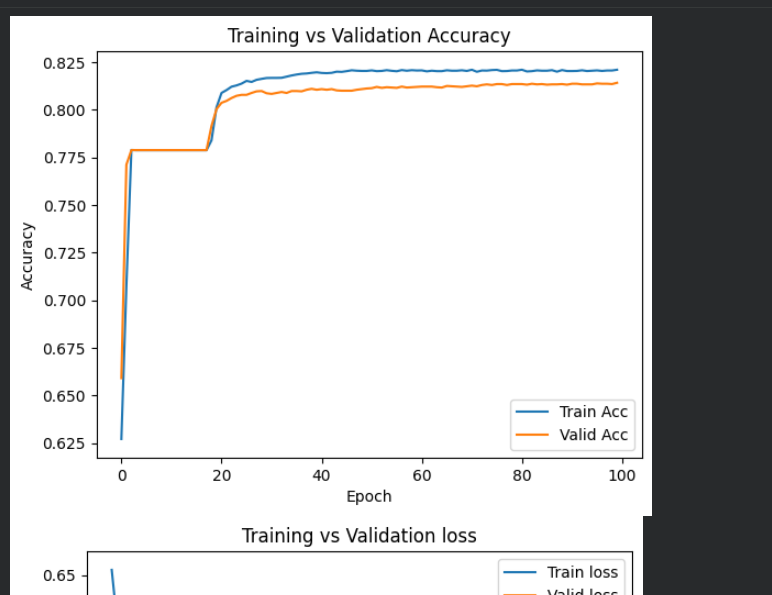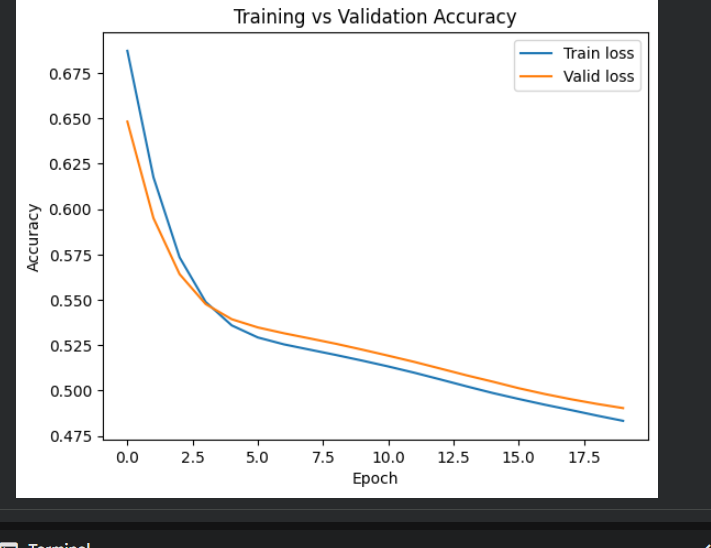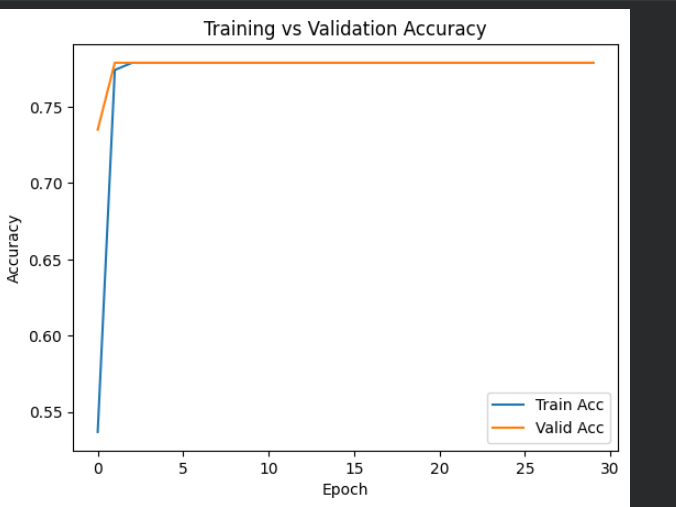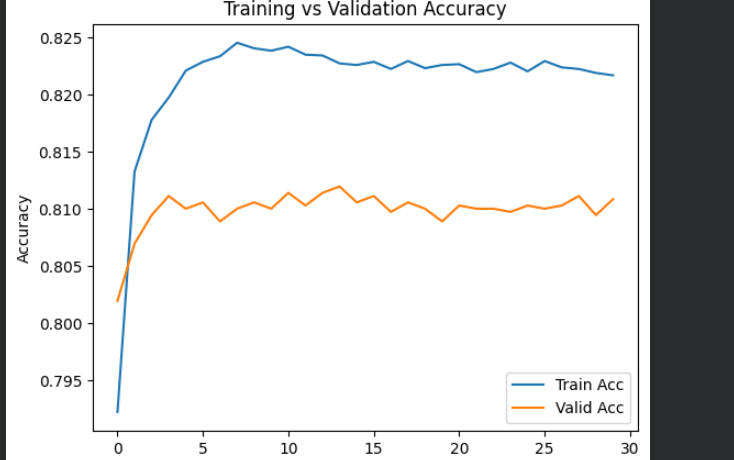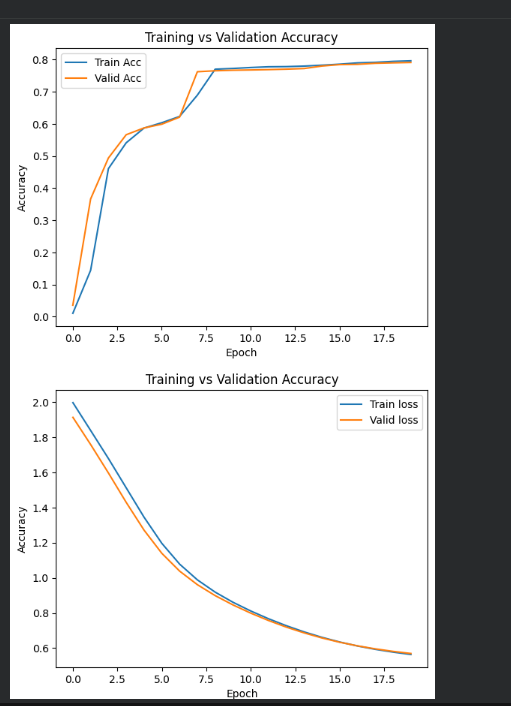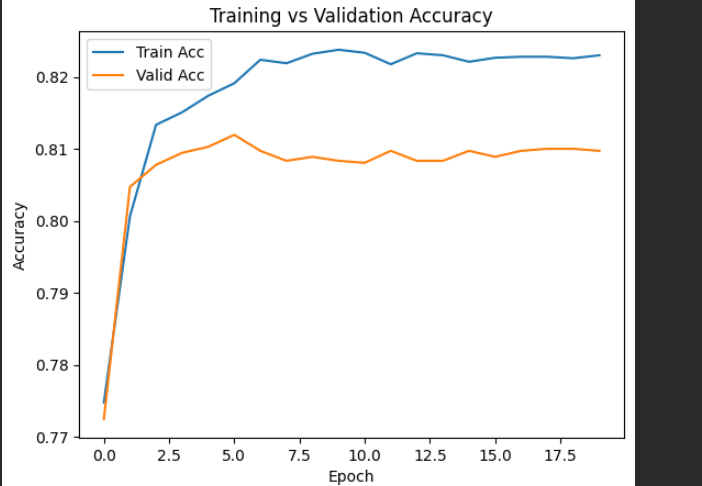


## 📝 Reflection
- What went well?
  * *I like the activation layers I used, I specifically chose them cause of how different they are.*
  
  * *I know sigmoid and softmax are mainly used for multiclass classification wich worked better to make val accuracy closer to train.*
  * *I like tanh as the top layer since the 23 neuros help prevent the model to get stuck on 78% and I wanted to balance the scale before getting to relu which needs a balance between 0 and positive numbers.*
- What didn’t?
  * *18000 on 32 batch size; horrible idea, never do it, the ops will slow.*
  * *I tried to throw a lot of spageti at the wall and see what sticks which made it harder to keep track of what worked and made the process more frustratiting than it could have been.*
- What would you do differently next time?

  * *Next time I will absolutely keep track of my choices from the beigining.*
  * *To fine tune the best, I learned (at least for this data set in particular) is for epochs to be low and batch size to be high it's easier on the ops and it made the curve validation curve closer to the train curve.*
  * *Acording to a tanh explanantion from claude; "Tanh is not or sigmoid are not good when fed with a lot of neurons", in this case I found the oposite to be true*
- How did your model meet your assigned mascot constraints?

  * *My model met my assigned mascot constratints by having multiple activation layers, all things considered it did not make my assignment harder honestly.*
  * *I did notice that overfiting was surprisingly hard to accomplish, even after 600, 1000, 1800 epochs (Yeah I put my computer through the test, google crashed a few times) the loss and validation curves did not deviate too much. My bigest problem was getting it to stop underfiting actually wich is why I ended up doing a 1000 batch size which at the start I didn't even think would affect the process to much.*